# Análise Exploratória de Dados

<hr>

O objetivo deste notebook é descrever os dados em termos de medidas de estatística. Medidas de posição, dispersão e correlação serão descritas, com aplicações em diferentes conjuntos de dados.

## 1. Visualização

Uma das maneiras mais simples de visualizar a distribuição dos dados é através de gráficos de frequência e histogramas.

Um exemplo de um gráfico de frequência:

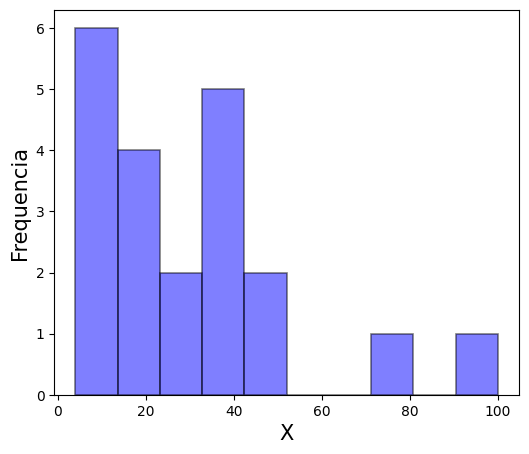

In [ ]:
import numpy as np
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt

x = [21,22,23,4,5,6,77,8,9,10,31,32,33,34,35,36,37,18,49,50,100]

fig= plt.figure(figsize=(6,5))

num_bins = 10
n, bins, patches = plt.hist(x, num_bins, facecolor='blue', alpha=0.5, density=False, edgecolor='black', linewidth=1.2)
plt.xlabel("X", fontsize = 15)
plt.ylabel("Frequencia", fontsize = 15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

No caso do histograma, a área sob a curva deve ser igual a 1 (notem a diferença na escala do eixo das ordenadas (y)).

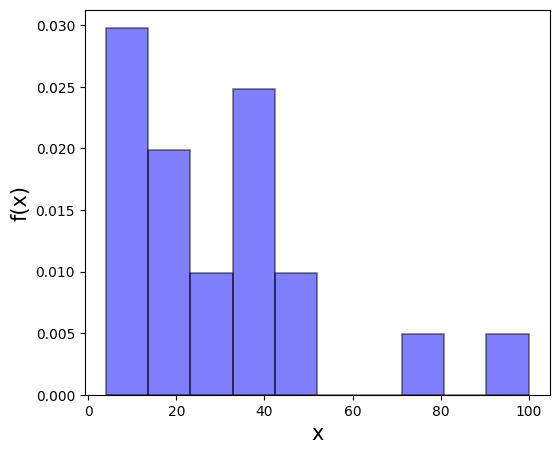

In [ ]:
import numpy as np
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt

x = [21,22,23,4,5,6,77,8,9,10,31,32,33,34,35,36,37,18,49,50,100]

fig= plt.figure(figsize=(6,5))

num_bins = 10
n, bins, patches = plt.hist(x, num_bins, facecolor='blue', alpha=0.5, density=True, edgecolor='black', linewidth=1.2)
plt.xlabel("x", fontsize = 15)
plt.ylabel("f(x)", fontsize = 15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# A diferença entre os dois gráficos é que o primeiro mostra a frequência absoluta de cada intervalo, 
# enquanto o segundo mostra a densidade de probabilidade, ou seja, a frequência relativa em relação ao total de dados. 
# No primeiro gráfico, a altura de cada barra representa o número de ocorrências em cada intervalo, 
# enquanto no segundo gráfico, a altura de cada barra representa a proporção de ocorrências em relação ao total de dados.

# Density=True normalize o histograma para que a área total seja igual a 1.

No caso de variáveis nominais, podemos usar gráficos de barra ou gráficos de setores. Notem que o valor no eixo das abscissas (x) é arbitrário e não deve ser levando em conta.

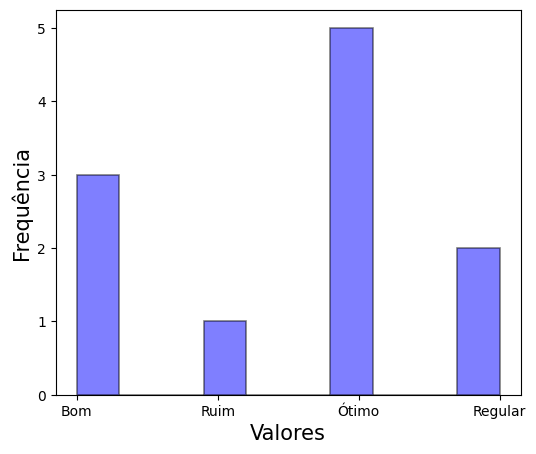

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = ["Bom", "Ruim", "Ótimo", "Regular", "Regular",
     "Ótimo", "Ótimo","Bom", "Ótimo", "Bom", "Ótimo"]

fig= plt.figure(figsize=(6,5))
plt.hist(data, facecolor='blue', alpha=0.5, edgecolor='black', linewidth=1.2)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("Valores",fontsize = 15)
plt.ylabel("Frequência", fontsize = 15)
plt.show()

Gráfico de setores:

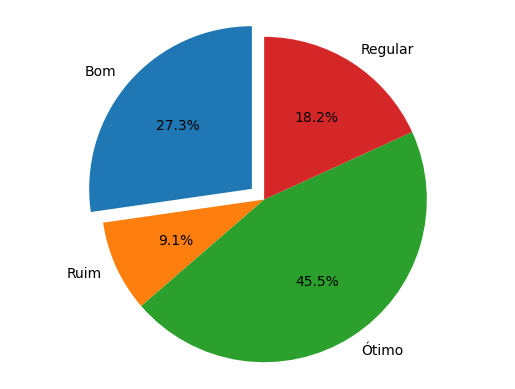

In [ ]:
import matplotlib.pyplot as plt

# Sample data 
labels = ['Bom', 'Ruim', 'Ótimo', 'Regular']
sizes = [data.count('Bom'), data.count('Ruim'), data.count('Ótimo'), data.count('Regular')]

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, explode = [0.1,0,0,0])
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.show()

O scatterplot é usado quando queremos verificar a relação entre duas variáveis.

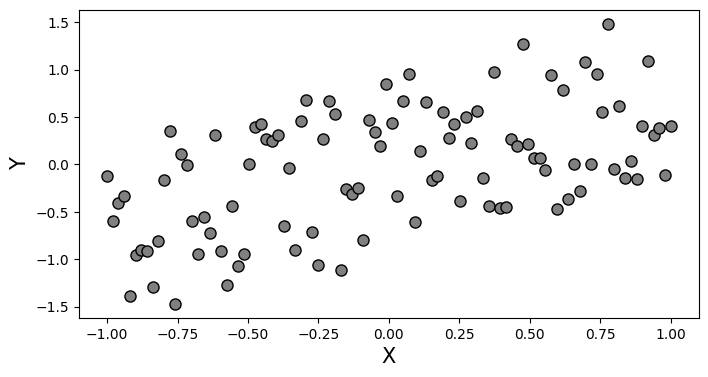

In [ ]:
N = 100
X = np.linspace(-1,1, N) # gera N valores em [-1,1]
erro = np.random.uniform(-1,1,N) # ruído a ser incluído na relação linear.
sigma= 1
Y = 0.8*X + erro*sigma

plt.figure(figsize=(8,4))
plt.plot(X, Y, 'o', color='gray', markersize=8,
         markerfacecolor='gray',
         markeredgecolor='black')
#plt.plot(X, Y, 'o');
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("X",fontsize = 15)
plt.ylabel("Y", fontsize = 15)
plt.show(True)

Quando temos três variáveis, uma maneira de visualizarmos os dados é considerar um gráfico de calor, sendo que a escala de cores define a terceira variável.

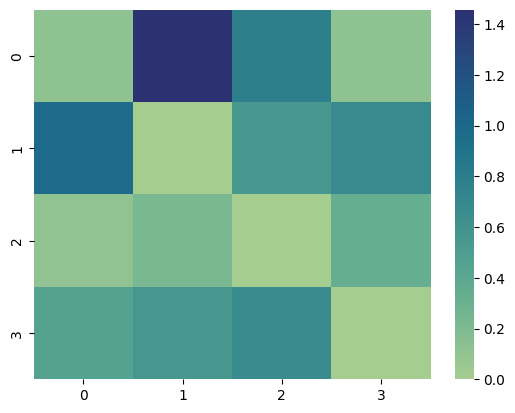

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

matrix = np.array([[0.1234, 1.4567, 0.7890, 0.1234],
                   [0.9876, 0, 0.5432, 0.6789],
                   [0.1111, 0.2222, 0, 0.3333],
                   [0.4444, 0.5555, 0.6666, 0]])
sns.heatmap(matrix, annot=False, cmap="crest")
plt.show()

Vários exemplos de visualização: https://python-graph-gallery.com/

<hr>

## 2. Medidas de posição

### 2.1 Moda

Uma medida importante de tendência central é a moda, que retorna o elemento mais comum em um conjunto de dados. Geralmente, essa medida é usada para atributos nominais.

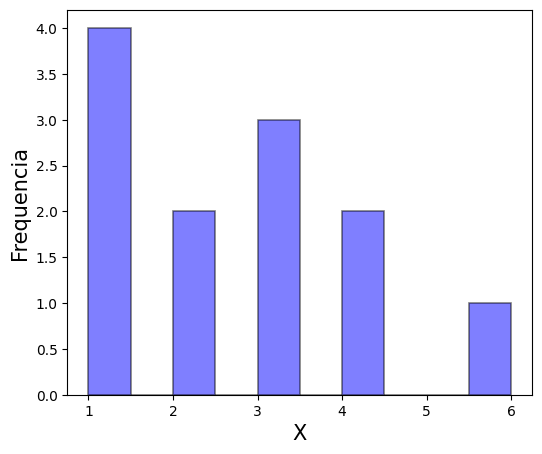

In [ ]:
import matplotlib.pyplot as plt

X = [1,2,3,1,2,3,4,1,3,6,4,1]

fig= plt.figure(figsize=(6,5))

n, bins, patches = plt.hist(X, facecolor='blue', alpha=0.5, density=False,
                            edgecolor='black', linewidth=1.2)
plt.xlabel("X", fontsize = 15)
plt.ylabel("Frequencia", fontsize = 15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

Para calcularmos a moda, usamos o pacote Statistics:

In [ ]:
from statistics import mode
X = [1,2,3,1,2,3,4,1,3,6,4,1]
m = mode(X)
print('A moda de X:', m)

A moda de X: 1


Podemos aplicar a função em dados nominais:

In [ ]:
Y = ["red", "blue", "blue", "red", "green", "red", "red"]
print('A moda de Y:', mode(Y))

A moda de Y: red


### 2.2 Média e Mediana

A média e mediana são medidas de tendência central usadas para dados quantitativos. Assim, a média:
$$
\bar{X} = \frac{1}{n} \sum_{i=1}^n x_i
$$

In [ ]:
def media(X):
    m = 0
    for x in X:
        m = m + x
    m = m/len(X)
    return m
X = [1,1,1,2,2,3,4,5,5,5]
mx = media(X)
print('X:', X)
print('A média:', mx)

X: [1, 1, 1, 2, 2, 3, 4, 5, 5, 5]
A média: 2.9


Podemos ainda usar um método da biblioteca Numpy.

In [ ]:
import numpy as np
X = [1,1,1,2,2,3,4,5,5,5]
mx = np.mean(X)
print('X:', X)
print('A média:', mx)

X: [1, 1, 1, 2, 2, 3, 4, 5, 5, 5]
A média: 2.9


No caso da mediana:

In [ ]:
X1 = [2,3,4,0,1,9,7]
print('X1 ordenado:', np.sort(X1))
md = np.median(X1)
print('X1:', X1)
print('A mediana:', md)
print('\n')
X2 = [2,3,4,0,1,9,7,0]
print('X2 ordenado:', np.sort(X2))
md = np.median(X2)
print('X2:', X2)
print('A mediana:', md)

X1 ordenado: [0 1 2 3 4 7 9]
X1: [2, 3, 4, 0, 1, 9, 7]
A mediana: 3.0


X2 ordenado: [0 0 1 2 3 4 7 9]
X2: [2, 3, 4, 0, 1, 9, 7, 0]
A mediana: 2.5


Se adicionarmos um valor extremo aos dados, vejamos como a média e a mediana se comportam:

In [ ]:
X1 = [1,1,1,2,2,3,4]
X2 = [1,1,1,2,2,3,10000]
print('A média:', np.mean(X1))
print('A nova média:', np.mean(X2))
print('\n')
print('A mediana:', np.median(X1))
print('A nova mediana:', np.median(X2))

A média: 2.0
A nova média: 1430.0


A mediana: 2.0
A nova mediana: 2.0


Ou seja, a média é altamente sensível a valores extremos, enquanto que a mediana é mais robusta.

Vamos considerar uma distribuição de probabilidades. Os dados são gerados a partir de distribuições normal e exponencial.

Para a distribuição normal (simétrica), a média é indicada pela linha contínua e a mediana, pela tracejada.

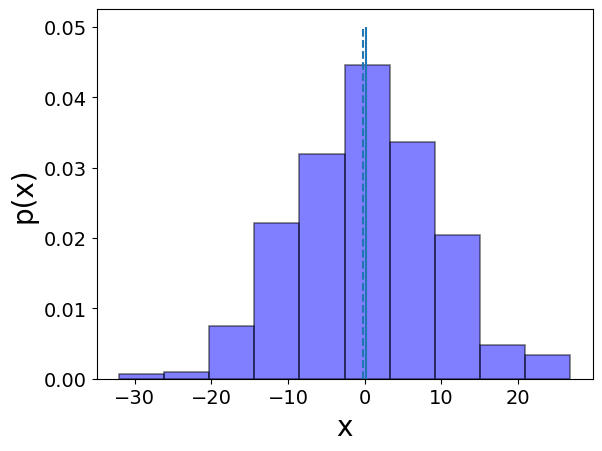

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 

mu = 0 # Média da distribuicao normal
sigma = 10 #desvio padrão da distribuição normal
Y = np.random.normal(mu, sigma, 500)
n, bins, patches = plt.hist(Y, facecolor='blue', alpha=0.5, density=True, edgecolor='black', linewidth=1.2)

m = np.mean(Y)
md = np.median(Y)
plt.vlines(m,0,0.05)
plt.vlines(md,0,0.05, linestyles = 'dashed')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("x",fontsize = 20)
plt.ylabel("p(x)", fontsize = 20)
plt.show(True)

Para a distribuição exponencial (assimétrica), a média é indicada pela linha contínua e a mediana, pela tracejada.

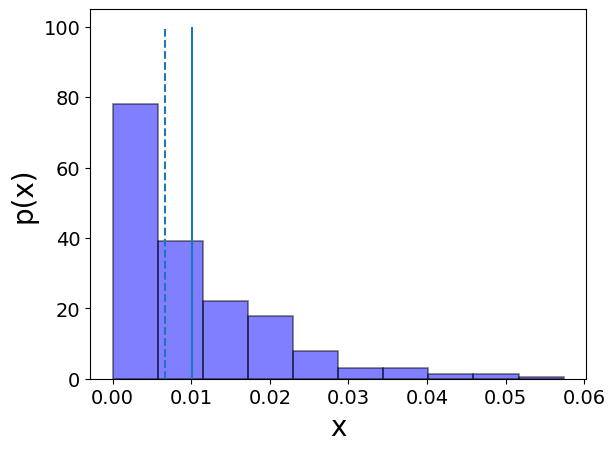

In [ ]:
import numpy as np
import matplotlib.pyplot as plt #biblioteca gráfica para mostrar os gráficos

lbda = 100 # taxa da distribuição exponencial
beta = 1.0/lbda

Y = np.random.exponential(beta, 500)
n, bins, patches = plt.hist(Y, facecolor='blue', alpha=0.5, density=True, edgecolor='black', linewidth=1.2)

m = np.mean(Y)
md = np.median(Y)
plt.vlines(m,0,lbda)
plt.vlines(md,0,lbda, linestyles = 'dashed')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("x",fontsize = 20)
plt.ylabel("p(x)", fontsize = 20)

plt.show(True)

Notamos que a média é similar à mediana se a distribuição é praticamente simétrica em relação à média. Caso a distribuição não seja simétrica, o mais adequado é usar a mediana como medida central.

### 2.3 Percentil

O percentil é uma medida estatística que indica a posição relativa de um valor dentro de um conjunto de dados, dividindo-o em 100 partes iguais. Ele expressa a porcentagem de valores no conjunto que estão abaixo de um determinado valor.
* Percentil 25 (ou primeiro quartil): 25% dos valores do conjunto são menores ou iguais a este valor.
* Percentil 50 (ou mediana): 50% dos valores estão abaixo ou no mesmo nível (é o valor central).
* Percentil 75 (ou terceiro quartil): 75% dos valores estão abaixo.


In [ ]:
import numpy as np

x = [5,7,3,8,12,15,18]
print('x:',x)
print('x ordenado:', np.sort(x))

print("Primeiro quartil (Q1):", np.percentile(x,25,interpolation='midpoint'))
print("Segundo quartil (Q2) ou Mediana:", np.percentile(x,50,interpolation='midpoint'))
print("Terceiro quartil (Q3):", np.percentile(x,75,interpolation='midpoint'))

x: [5, 7, 3, 8, 12, 15, 18]
x ordenado: [ 3  5  7  8 12 15 18]
Primeiro quartil (Q1): 6.0
Segundo quartil (Q2) ou Mediana: 8.0
Terceiro quartil (Q3): 13.5


<img src="https://www.w3schools.com/statistics/img_histogram_quartiles.svg" width=700/>

Para visualizar os quantis, podemos usar o boxplot:

<img src="https://miro.medium.com/v2/resize:fit:1400/1*0MPDTLn8KoLApoFvI0P2vQ.png" width=700/>

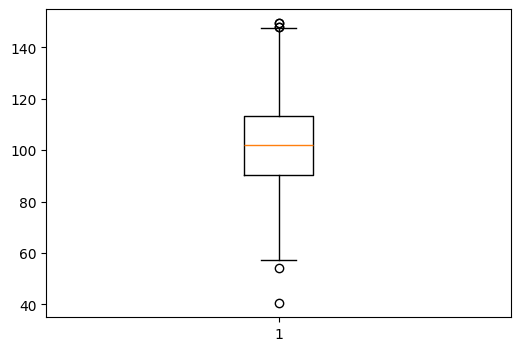

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(10)
data = np.random.normal(100, 20, 200)

fig = plt.figure(figsize =(6, 4))
plt.boxplot(data)
plt.show()

Podemos visualizar as variáveis em uma base de dados.

In [ ]:
import pandas as pd

#from google.colab import drive
#drive.mount('/content/drive/')
#data = pd.read_csv('/content/drive/My Drive/dados/iris.csv', header=(0))

csv_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
col_names = ['Sepal_Length','Sepal_Width','Petal_Length','Petal_Width','Class']
data =  pd.read_csv(csv_url, names = col_names)

data.head(10)

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


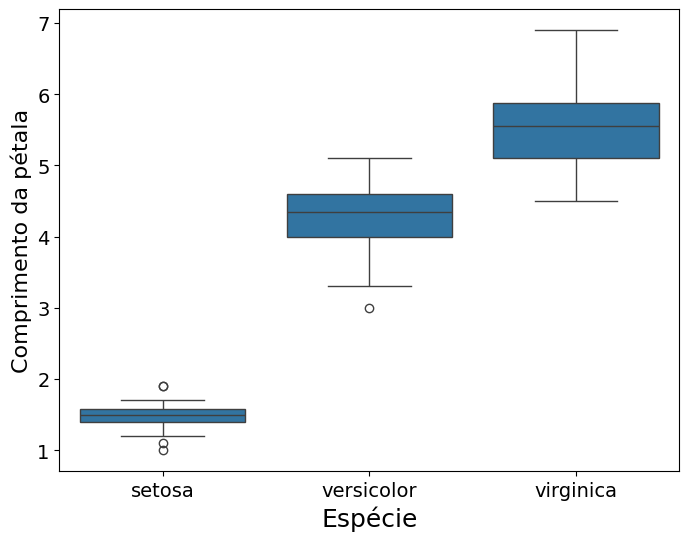

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.boxplot(x="species", y="petal_length", data=data)
plt.xlabel('Espécie', fontsize=18)
plt.ylabel('Comprimento da pétala', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show(True)

Outro gráfico importante é o gráfico de violino.

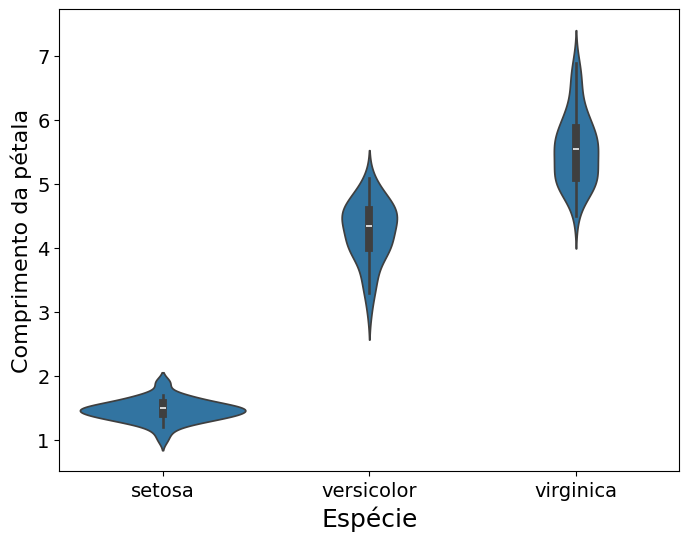

In [ ]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.violinplot(data=data, x="species", y="petal_length")
plt.xlabel('Espécie', fontsize=18)
plt.ylabel('Comprimento da pétala', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show(True)

Swarm plot:

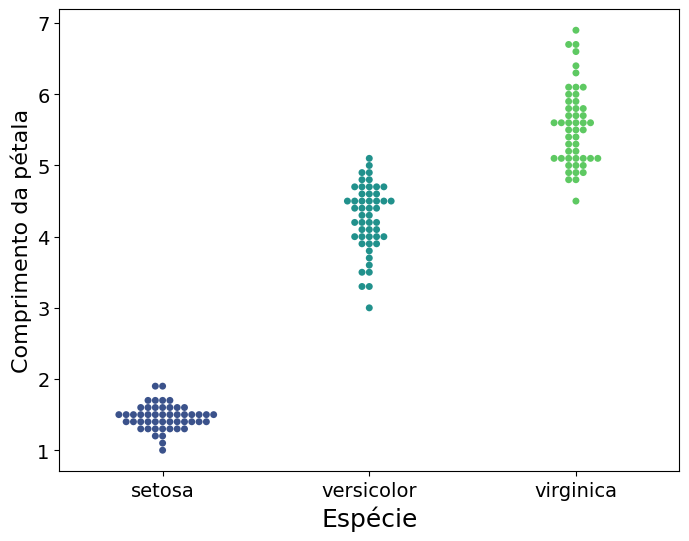

In [ ]:
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

plt.figure(figsize=(8, 6))
sns.swarmplot(data=data, x="species", y="petal_length", palette='viridis')
plt.xlabel('Espécie', fontsize=18)
plt.ylabel('Comprimento da pétala', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show(True)

<hr>

## 3. Medidas de dispersão

As medidas de dispersão mais usadas são a variância e o desvio padrão. A distância interquantil (IQR) também é bastante usada e quantifica a diferença entre o terceiro e primeiro quantil. Já a amplitude simplesmente mede a diferença entre os valores máximo e mínimo.

In [ ]:
from scipy.stats import iqr

def variancia(X):
    m = np.mean(X)
    N = len(X)
    s = 0
    for i in np.arange(0, len(X)):
        s = s + (X[i]-m)**2
    s = s/(N-1)
    return s

X = [0,0,1,1,18]
Y = [4, 4, 4, 4, 4]
mx = np.mean(X)
my = np.mean(Y)
print('X:', X)
print('Média de X:', mx)
print('Variância de X:', variancia(X))
print('IQR de X:', iqr(X))
print('Amplitude de X:', np.max(X)-np.min(X))

print('\n')
print('Y:', Y)
print('Média de Y:', my)
print('Variância de Y:', variancia(Y))
print('IQR de Y:', iqr(Y))
print('Amplitude de Y:', np.max(Y)-np.min(Y))

X: [0, 0, 1, 1, 18]
Média de X: 4.0
Variância de X: 61.5
IQR de X: 1.0
Amplitude de X: 18


Y: [4, 4, 4, 4, 4]
Média de Y: 4.0
Variância de Y: 0.0
IQR de Y: 0.0
Amplitude de Y: 0


Notem que os dados acima possuem a mesma média, mas a variância é bastante diferente.

## 4. Resumo descritivo

Para obtermos um resumo das medidas estatística dos dados:

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive/')

data = pd.read_csv('/content/drive/My Drive/dados/iris.csv', header=(0))

data.describe()

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


<hr>

## 5. Correlação

### 5.1 Correlação de Pearson

Vamos considerar alguns casos para vermos como se comporta o coeficiente de correlação de Pearson de acordo com diferentes tendências entre as variáveis $X$ e $Y$.

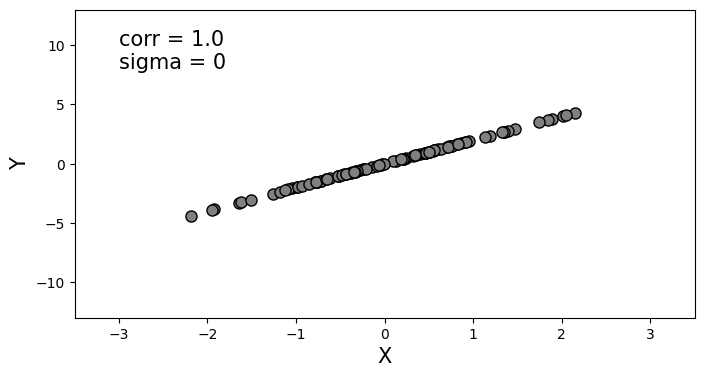

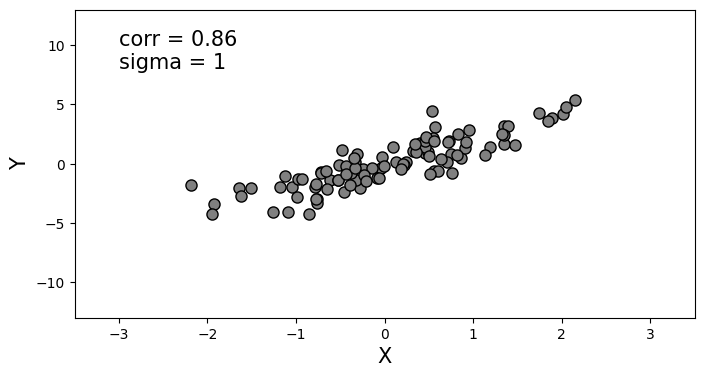

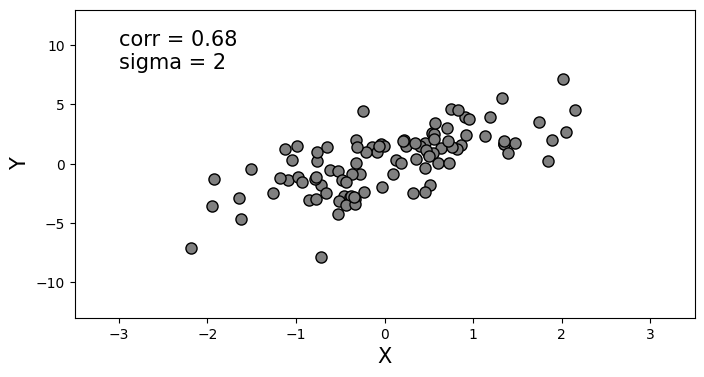

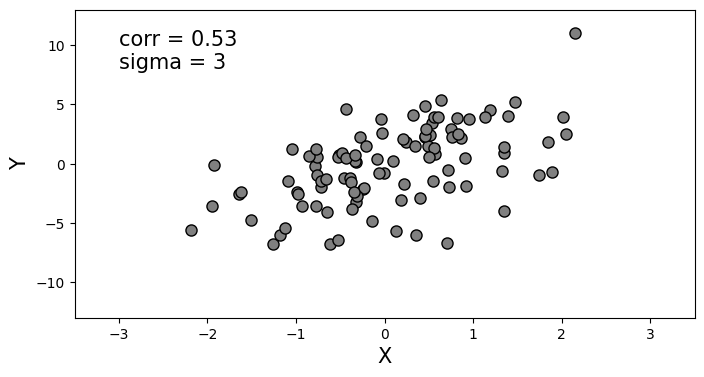

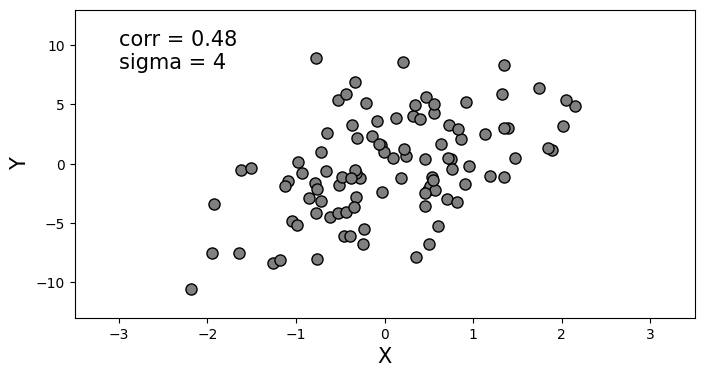

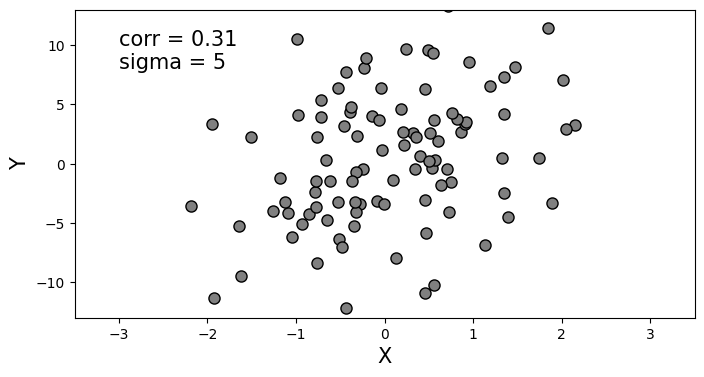

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
np.random.seed(13)

# Generate data from a normal distribution
N = 100
X = np.random.normal(0, 1, N)  # Mean 0, standard deviation 1

for sigma in np.arange(0, 6, 1):
    error = np.random.normal(0, sigma, N)
    Y = 2 * X + error
    corr, p_value = pearsonr(X, Y)

    plt.figure(figsize=(8, 4))
    plt.xlim(-3.5,3.5)
    plt.ylim(-13,13)
    plt.plot(X, Y, 'o', color='gray', markersize=8,
             markerfacecolor='gray',
             markeredgecolor='black')
    plt.xlabel("X", fontsize=15)
    plt.ylabel("Y", fontsize=15)
    corr = int(corr * 100) / 100
    string = 'corr = ' + str(corr) + '\nsigma = ' + str(sigma)
    plt.text(-3,8, string, fontsize=15)
    plt.show()

A medida de correlação é importante para analisar a relação entre as variáveis. Se duas variáveis são altamente correlacionadas, é adequado remover uma delas, de modo a reduzir informação redundante nos dados.

Dataframe : 
    x   y   z
0  45  38  10
1  37  31  15
2  42  26  17
3  35  28  21
4  39  33  12
Matriz de correlação : 
          x         y         z
x  1.000000  0.518457 -0.701886
y  0.518457  1.000000 -0.860941
z -0.701886 -0.860941  1.000000


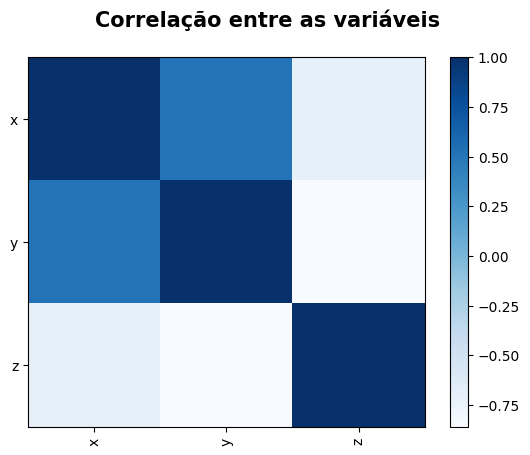

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'x': [45, 37, 42, 35, 39],
    'y': [38, 31, 26, 28, 33],
    'z': [10, 15, 17, 21, 12]
}

# cria um dataframe
dataframe = pd.DataFrame(data, columns=['x', 'y', 'z'])
print("Dataframe : ")
print(dataframe)

# matriz de correlação
corr = dataframe.corr()
print("Matriz de correlação : ")
print(corr)

plt.imshow(corr, cmap='Blues', interpolation='none', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation='vertical')
plt.yticks(range(len(corr)), corr.columns);
plt.suptitle('Correlação entre as variáveis', fontsize=15, fontweight='bold')
plt.grid(False)
plt.show()

Vamos considerar a base de dados da flor Iris:

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


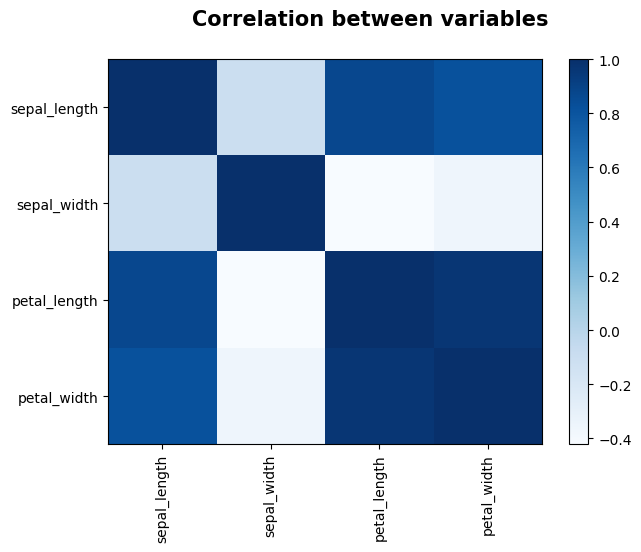

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive/')
data = pd.read_csv('/content/drive/My Drive/dados/iris.csv', header=(0))

# remove a última coluna
data = data.drop(data.columns[-1],axis=1)
corr = data.corr()
#Plot Correlation Matrix using Matplotlib
plt.figure(figsize=(7, 5))
plt.imshow(corr, cmap='Blues', interpolation='none', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation='vertical')
plt.yticks(range(len(corr)), corr.columns);
plt.suptitle('Correlation between variables', fontsize=15, fontweight='bold')
plt.grid(False)
plt.show()

Podemos mostrar a mesma tabela usando a biblioteca Searborn:

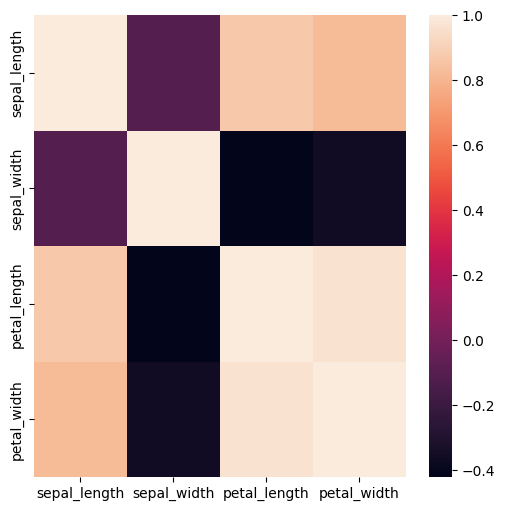

In [ ]:
import seaborn as sns
plt.figure(figsize= (6, 6))
sns.heatmap(data.corr())
plt.show(sns)

Pair plot:

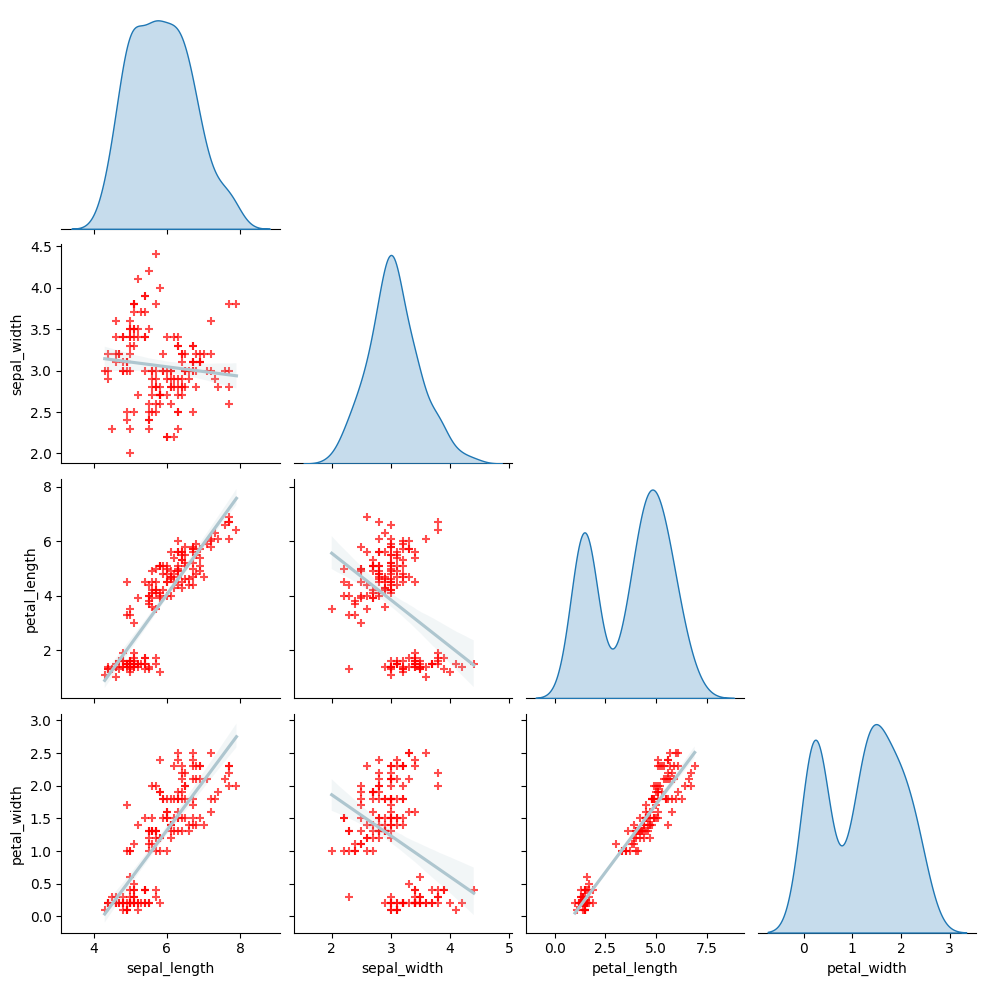

In [ ]:
sns.pairplot(data,
                 markers="+",
                 diag_kind="kde",
                 kind='reg',
                 plot_kws={'line_kws':{'color':'#aec6cf'},
                           'scatter_kws': {'alpha': 0.7,
                                           'color': 'red'}},
                 corner=True);

### 5.2 Correlação de Spearman

Além do coeficiente de Pearson, podemos considerar o coeficiente de correlação de Spearman:

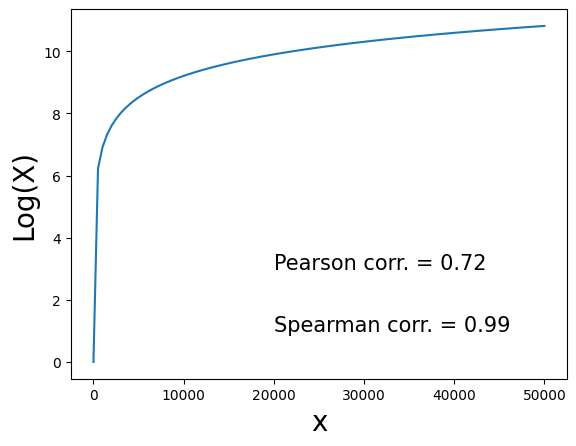

Pearson: 0.72
Spearman: 0.99


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

N = 100
x = np.linspace(1, 50000, N)
z = np.log(x)

plt.plot(x, z)
plt.xlabel("x",fontsize = 20)
plt.ylabel("Log(X)", fontsize = 20)
corr, p_value = pearsonr(x, z)
corrs, p_values = spearmanr(x, z)
corr = int(corr*100)/100
corrs = int(corrs*100)/100
string = 'Pearson corr. = '+ str(corr)
plt.text(20000,3, string, fontsize=15)
string = 'Spearman corr. = '+ str(corrs)
plt.text(20000,1, string, fontsize=15)
plt.show()
print("Pearson:",corr)
print("Spearman:",corrs)

Notem que nesse caso, os coeficientes de Spearman e Pearson são diferentes.

### Implementação das correlações de Pearon e Spearman

Vamos considerar um exemplo numérico para obtermos mais intuição sobre o cálculo dessas medidas.

Text(0, 0.5, 'y')

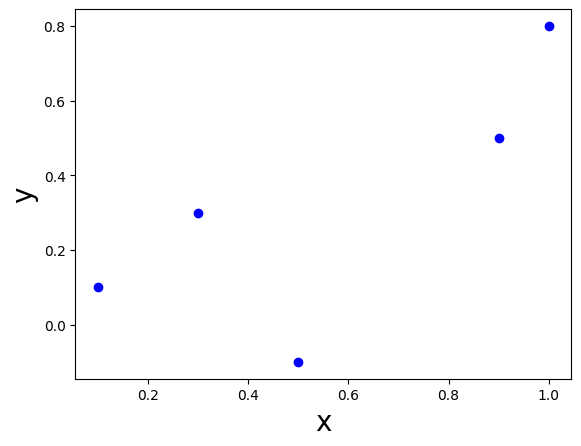

In [ ]:
x = [0.9,0.5, 0.3, 0.1, 1.0]
y = [0.5, -0.1, 0.3, 0.1, 0.8]
#x = np.random.normal(0,1,100)
#y = 2*x + 3 + np.random.normal(0,1,100)
plt.plot(x, y, 'bo')
plt.xlabel("x",fontsize = 20)
plt.ylabel("y", fontsize = 20)

O coeficiente de correlação de Pearson:
$$
\rho ={\frac {\sum _{i=1}^{n}(x_{i}-{\bar {x}})(y_{i}-{\bar {y}})}{{\sqrt {\sum _{i=1}^{n}(x_{i}-{\bar {x}})^{2}}}\cdot {\sqrt {\sum _{i=1}^{n}(y_{i}-{\bar {y}})^{2}}}}}
$$

Vamos implementar uma função para calculá-lo.

Uma função para calcular a variância:

In [ ]:
def std(x):
    n = len(x)
    xm = 0
    for i in range(0,n):
        xm = xm + x[i]
    xm = xm/n
    std = 0
    for i in range(0,n):
        std = std + (x[i]-xm)**2
    std = np.sqrt(std/(n))
    return std

print("Valor calculado pela função:", std(x))
print("Valor calculado com o Numpy:", np.std(x))

Valor calculado pela função: 0.3440930106817051
Valor calculado com o Numpy: 0.3440930106817051


E o coeficiente de Pearson:

In [ ]:
from scipy.stats import pearsonr, spearmanr

def Pearson(x,y):
    n = len(x)
    # averages
    xm = 0
    ym = 0
    for i in range(0,n):
        xm = xm + x[i]
        ym = ym + y[i]
    xm = xm/n
    ym = ym/n
    r = 0
    for i in range(0,n):
        r = r + (x[i]-xm)*(y[i]-ym)
    r = r/n
    r = r/(std(x)*std(y))
    return r
print("Valor calculado pela função:", Pearson(x,y))
print("Valor calculado usando o pacote statistics:", pearsonr(x, y)[0])

Valor calculado pela função: 0.7516412406984152
Valor calculado usando o pacote statistics: 0.7516412406984154


No caso do coeficiente de Spearman, vamos obter os valores ordenados de x e y.

In [ ]:
print('x:', x)
print('\n')
print('Sorted x:', [sorted(x).index(i)+1 for i in x])
print('\n')
print('y:', y)
print('\n')
print('Sorted y:', [sorted(y).index(i)+1 for i in y])

x: [0.9, 0.5, 0.3, 0.1, 1.0]


Sorted x: [4, 3, 2, 1, 5]


y: [0.5, -0.1, 0.3, 0.1, 0.8]


Sorted y: [4, 1, 3, 2, 5]


In [ ]:
xr = [sorted(x).index(i)+1 for i in x]
yr = [sorted(y).index(i)+1 for i in y]
print("Valor calculado pela função:", Pearson(xr,yr))
print("Valor calculado usando o pacote statistics:", spearmanr(xr, yr)[0])

Valor calculado pela função: 0.6999999999999998
Valor calculado usando o pacote statistics: 0.7


Logo, vemos que o coeficiente de Spearman nada mais é do que o coeficiente de Pearson aplicado à ordem dos valores.

## 6. Análise dos componentes principais

Podemos implementar o PCA usando decomposição SVD:

In [ ]:
import numpy as np

def pca_matrix_diagonalization(X, n_components):
    # Calculate the covariance matrix
    covariance_matrix = np.cov(X, rowvar=False)

    # Calculate eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

    # Sort eigenvalues and eigenvectors in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]

    # Select the top n_components eigenvectors
    principal_components = eigenvectors[:, :n_components]

    # Project the data onto the principal components
    projected_data = X @ principal_components

    return projected_data, eigenvalues, eigenvectors

Vamos ler os dados da flor iris novamente.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
drive.mount('/content/drive/')
data = pd.read_csv('/content/drive/My Drive/dados/iris.csv', header=(0))

#csv_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
#col_names = ['Sepal_Length','Sepal_Width','Petal_Length','Petal_Width','Class']
#data =  pd.read_csv(csv_url, names = col_names)

data.head(10)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


Podemos projetos os dados em duas dimensões.

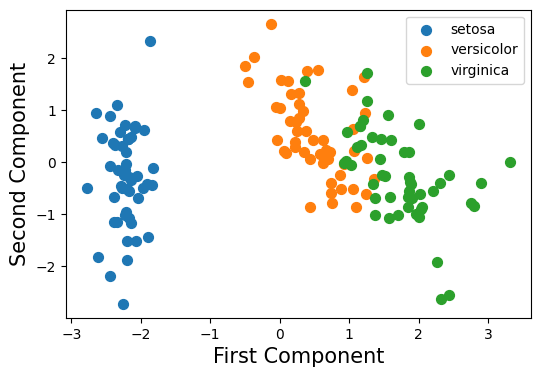

In [ ]:
# Prepare the data
data = data.to_numpy()
nrow, ncol = data.shape
y = data[:, -1]
X = data[:, 0:ncol - 1]

# Standardize the features
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

# Project the data using pca_matrix_diagonalization
projected_data, eigenvalues, eigenvectors = pca_matrix_diagonalization(X_scaled, 2)

# Visualize the projected data
plt.figure(figsize=(6, 4))
for label in np.unique(y):
    plt.scatter(projected_data[y == label, 0], projected_data[y == label, 1], label=label, s=50)
plt.xlabel("First Component", fontsize=15)
plt.ylabel("Second Component", fontsize=15)
plt.xticks(color='k', size=10)
plt.yticks(color='k', size=10)
plt.legend()
plt.show()

Podemos ainda usar a biblioteca sklearn.

Vamos construir as variáveis $X$ e $Y$, sendo que $X$ representa os atributos e $Y$ as classes, respectivamente.

In [ ]:
data = data.to_numpy() #valido apenas para a versao do Pandas maior do que 0.24.0
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

Vamos padronizar os dados, de modo a evitar o efeito da escala dos atributos.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X)
X = scaler.transform(X)

Relizando a análise dos componentes principais:

In [ ]:
from sklearn.decomposition import PCA
# seleciona os dois componentes principais
pca = PCA(n_components=2)
# calcula o PCA
pca_result = pca.fit_transform(X)

Os dados projetados em duas dimensões.

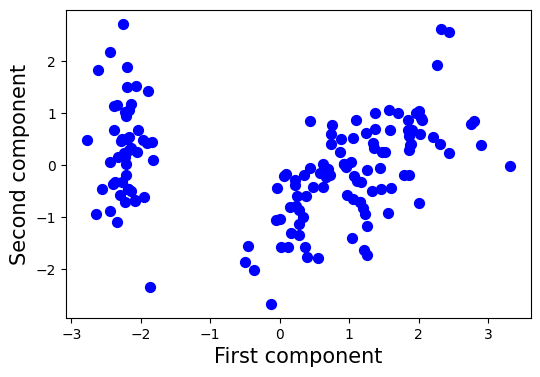

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(pca_result[:,0], pca_result[:,1], s=50, color = 'blue')
plt.xlabel("First component", fontsize=15)
plt.ylabel("Second component", fontsize=15)
plt.xticks(color='k', size=10)
plt.yticks(color='k', size=10)
plt.show(True)

Podemos colorir de acordo com as classes:

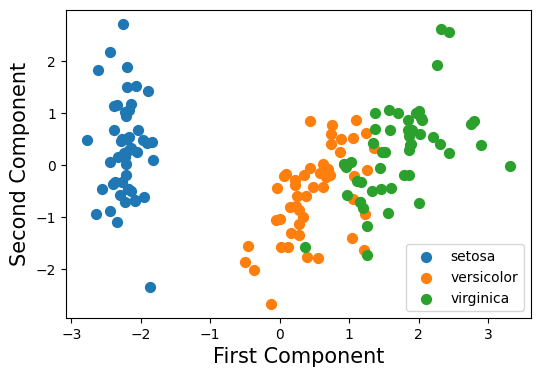

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Assuming 'data' is your DataFrame as in the provided code
# and X and y are already defined (features and classes)

# Standardize the features
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# Create the scatter plot, coloring by class
plt.figure(figsize=(6, 4))
for label in np.unique(y):
    plt.scatter(pca_result[y == label, 0], pca_result[y == label, 1], label=label, s=50)
plt.xlabel("First Component", fontsize=15)
plt.ylabel("Second Component", fontsize=15)
plt.xticks(color='k', size=10)
plt.yticks(color='k', size=10)
plt.legend()
plt.show()

Para estimarmos o número de componentes para projetarmos os dados, podemos analisar como a variância muda de acordo com o número de componentes.

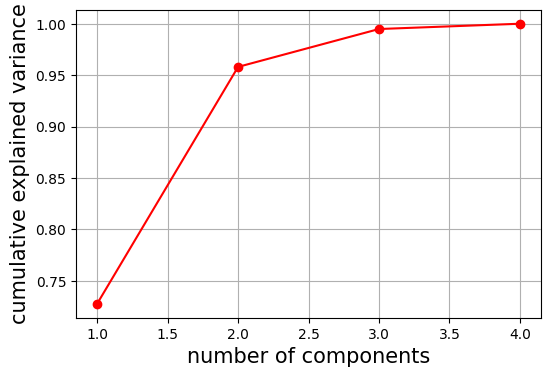

In [ ]:
pca = PCA().fit(X)
plt.figure(figsize=(6,4))
ncomp = np.arange(1, np.shape(X)[1]+1)
# mostra a variância acumulada
plt.plot(ncomp, np.cumsum(pca.explained_variance_ratio_), 'ro-')
plt.xlabel('number of components', fontsize=15)
plt.ylabel('cumulative explained variance', fontsize=15);
plt.xticks(color='k', size=10)
plt.yticks(color='k', size=10)
plt.grid(True)
plt.show(True)